<a href="https://colab.research.google.com/github/muthutaj2323a/Final-Year-Project-Muthu/blob/main/Hyper_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Automated Detection of Potato Leaf Diseases Using Deep Convolutional Neural Networks**

# **Download and Nested Extraction**
This block downloads the main zip and then extracts the inner Potato Image.zip file identified in your screenshot.

In [ ]:
import os
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from PIL import Image

# Download the dataset ---
!wget https://data.mendeley.com/public-api/zip/ttgtfp3vjb/download/1 -O dataset.zip

#  Extract main zip ---
with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('main_folder')

#  Extract the inner image zip ---
# Based on your file path: main_folder/Potato disease classification/Potato Image.zip
inner_zip_path = 'main_folder/Potato disease classification/Potato Image.zip'
data_dir = 'extracted_images'

with zipfile.ZipFile(inner_zip_path, 'r') as zip_ref:
    zip_ref.extractall(data_dir)

print("Data extracted to:", data_dir)

--2026-02-21 09:28:25--  https://data.mendeley.com/public-api/zip/ttgtfp3vjb/download/1
Resolving data.mendeley.com (data.mendeley.com)... 162.159.133.86, 162.159.130.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.133.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/ttgtfp3vjb-1.zip?X-Amz-Security-Token=IQoJb3JpZ2luX2VjEOH%2F%2F%2F%2F%2F%2F%2F%2F%2F%2FwEaCWV1LXdlc3QtMSJHMEUCIQCqH1VwUHyYvTj5l%2FeaYcxUYJfCwOyvkxxAWeAPIIbB%2FgIgMjNSsg8TAqj016bALfUXrMrFkzEtphVIWFNiBBOnQMUqlQUIqv%2F%2F%2F%2F%2F%2F%2F%2F%2F%2FARAEGgwzNjcxNDczODM4MjUiDAQe%2FhZRvyNjf%2BiHWirpBPJPQyaHorij1u3LZObEjcVBP3udaUGbxq3D4ELtnBi7yvFpE4J11bvtcc3KjNlhkkNjb0G4tQWlWMu8NX0UXPuaptY3JsdLVJcb3tKokaBY1yAaWtAHSGlEHwtllCpXD%2FfJphcVB6Ak0AxbGHJE%2Fc%2FKtYrDu3f85inpP%2BnDAqTthozpyjkcKMXEqmgC9e2VEsH1DtbmQ4BiUGM%2FriptoEMdLy9lmXj3apHEVG33LbJMwOftD8BJ6KJBCUbNd%2BeexgbgTA1hSz%2FGc099Zaj8Y4pluD7yHHzvmj3FuQwahpzoDPrey0Exp73T

# **Exploratory Data Analysis (EDA)**
For image datasets, EDA focuses on class balance (statistics) and visual inspection of samples.

/tmp/ipython-input-614863341.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(stats.keys()), y=list(stats.values()), palette="magma")


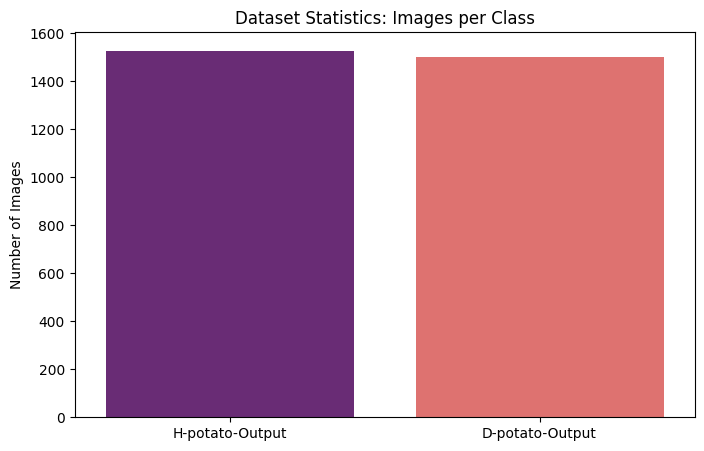

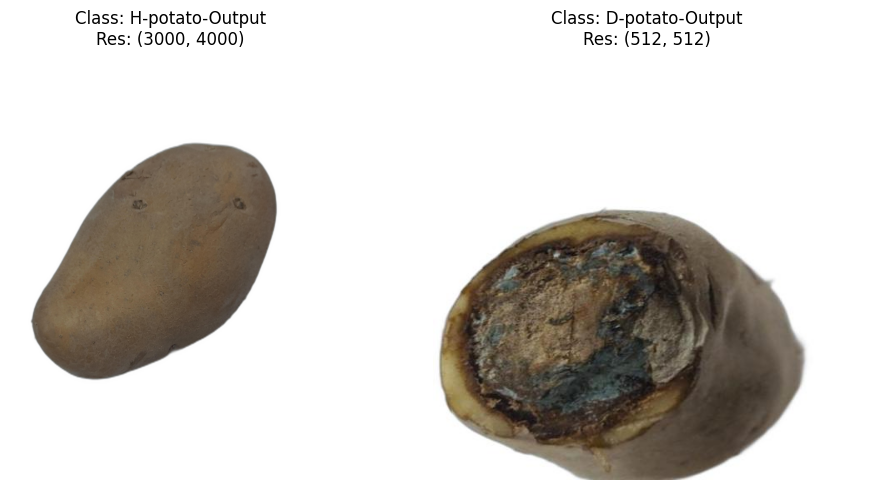

In [ ]:
# Define the path where the class folders (D-potato, H-potato) actually live
base_data_path = os.path.join(data_dir, 'Potato Image')

# Get the class names (D-potato-Output, H-potato-Output)
classes = [d for d in os.listdir(base_data_path) if os.path.isdir(os.path.join(base_data_path, d))]

# --- Statistics: Image Counts ---
stats = {cls: len(os.listdir(os.path.join(base_data_path, cls))) for cls in classes}

plt.figure(figsize=(8, 5))
sns.barplot(x=list(stats.keys()), y=list(stats.values()), palette="magma")
plt.title("Dataset Statistics: Images per Class")
plt.ylabel("Number of Images")
plt.show()

# --- Visualization: Sample Images ---
plt.figure(figsize=(10, 5))
for i, cls in enumerate(classes):
    # Get the first image file in the directory
    img_list = os.listdir(os.path.join(base_data_path, cls))
    img_path = os.path.join(base_data_path, cls, img_list[0])
    img = Image.open(img_path)

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(f"Class: {cls}\nRes: {img.size}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Preprocessing for Deep Learning**
This block prepares the data for a training pipeline by resizing the images and creating a validation split.

In [ ]:
IMG_SIZE = 256
BATCH_SIZE = 32

# Create the training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_data_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# Normalization (Scaling pixels from 0-255 to 0-1)
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

print("Preprocessing complete: Data normalized and ready for model input.")

Found 3027 files belonging to 2 classes.
Using 2422 files for training.
Preprocessing complete: Data normalized and ready for model input.


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow.keras import layers, models, applications

IMG_SIZE = 224 # Standard for most pre-trained models
BATCH_SIZE = 32

# Data Augmentation & Loading
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

# Update 'base_data_path' to your local directory
train_generator = train_datagen.flow_from_directory(
    base_data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    base_data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 2422 images belonging to 2 classes.
Found 605 images belonging to 2 classes.


## **ADAM**

In [ ]:
def build_model(base_arch, num_classes):
    base_model = base_arch(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    # FIX: Corrected the loss identifier string
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

num_classes = len(train_generator.class_indices)

models_dict = {
    "ResNet50": build_model(applications.ResNet50, num_classes),
    "MobileNetV2": build_model(applications.MobileNetV2, num_classes),

    "InceptionV3": build_model(applications.InceptionV3, num_classes)
}

In [ ]:
history_logs = {}
performance_metrics = {}

for name, model in models_dict.items():
    print(f"\n--- Training {name} ---")
    start_train = time.time()
    history = model.fit(train_generator, validation_data=val_generator, epochs=10)
    performance_metrics[name] = {"train_time": time.time() - start_train}
    history_logs[name] = history

# Re-initialize a clean validation generator for testing (No Shuffle)
test_generator = train_datagen.flow_from_directory(
    base_data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False  # CRITICAL for Confusion Matrix
)


--- Training ResNet50 ---
Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.5164 - loss: 0.8365 - val_accuracy: 0.7636 - val_loss: 0.5821
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.7006 - loss: 0.6006 - val_accuracy: 0.6083 - val_loss: 0.6269
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.7214 - loss: 0.5584 - val_accuracy: 0.8000 - val_loss: 0.4992
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.7671 - loss: 0.5119 - val_accuracy: 0.7554 - val_loss: 0.5019
Epoch 5/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.7573 - loss: 0.5041 - val_accuracy: 0.8083 - val_loss: 0.4666
Epoch 6/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.7524 - loss: 0.5118 - val_accuracy: 0.7884 - val_loss: 0.4755
Epoch 7/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.7899 - loss: 0.4687 - val_accuracy: 0.7785 - val_loss: 0.4615
Epoch 8/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.7733 - loss: 0.4714

19/19 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step

ResNet50 RESULTS
Test Time (Total): 35.56s
                 precision    recall  f1-score   support

D-potato-Output       0.81      0.80      0.80       300
H-potato-Output       0.80      0.82      0.81       305

       accuracy                           0.81       605
      macro avg       0.81      0.81      0.81       605
   weighted avg       0.81      0.81      0.81       605



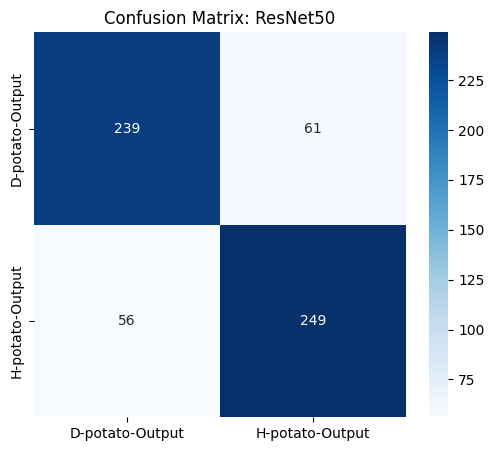

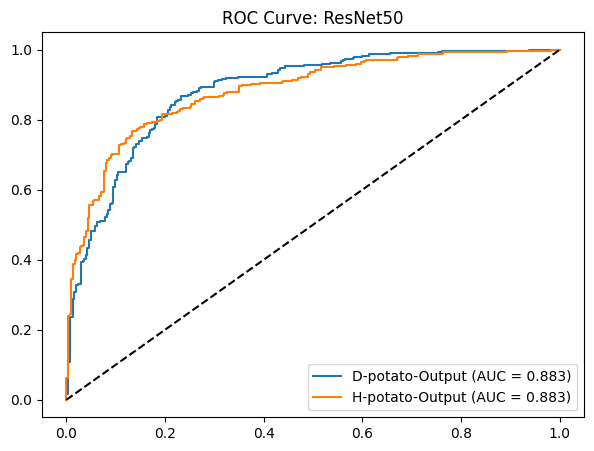

19/19 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step

MobileNetV2 RESULTS
Test Time (Total): 36.55s
                 precision    recall  f1-score   support

D-potato-Output       0.99      1.00      0.99       300
H-potato-Output       1.00      0.99      0.99       305

       accuracy                           0.99       605
      macro avg       0.99      0.99      0.99       605
   weighted avg       0.99      0.99      0.99       605



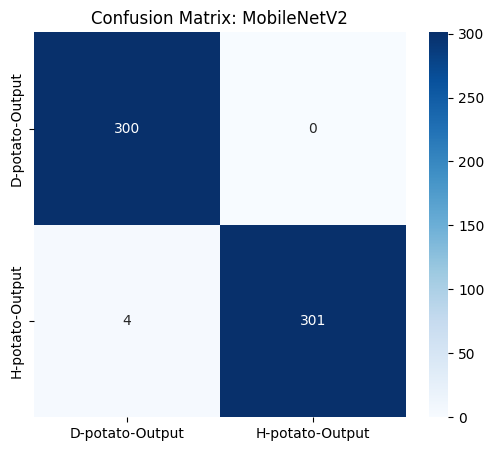

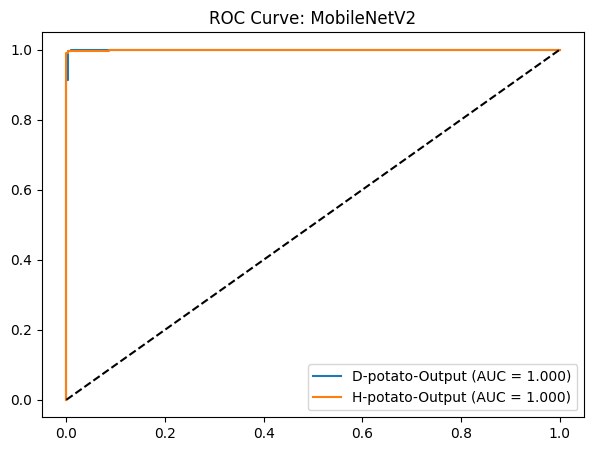

19/19 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step

InceptionV3 RESULTS
Test Time (Total): 39.20s
                 precision    recall  f1-score   support

D-potato-Output       0.96      1.00      0.98       300
H-potato-Output       1.00      0.95      0.97       305

       accuracy                           0.98       605
      macro avg       0.98      0.98      0.98       605
   weighted avg       0.98      0.98      0.98       605



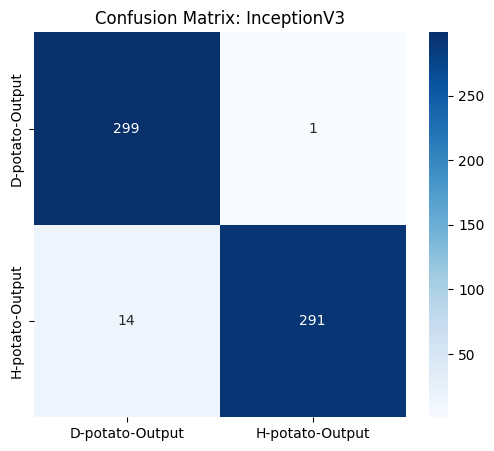

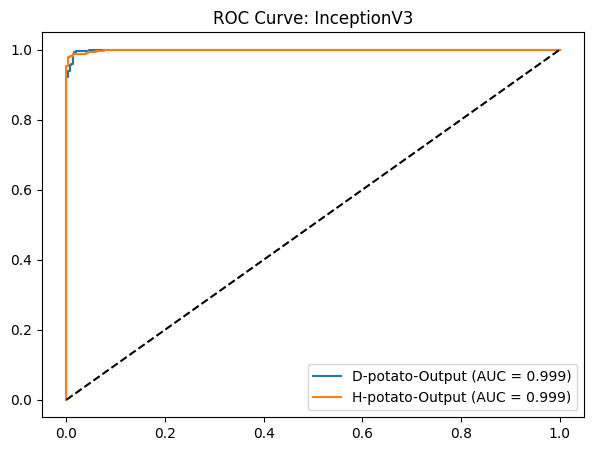

In [ ]:
def evaluate_model(name, model, generator):
    start_test = time.time()
    y_pred_probs = model.predict(generator)
    test_time = time.time() - start_test

    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.classes
    class_labels = list(generator.class_indices.keys())

    # Metrics
    print(f"\n{'='*20}\n{name} RESULTS\n{'='*20}")
    print(f"Test Time (Total): {test_time:.2f}s")
    print(classification_report(y_true, y_pred, target_names=class_labels))

    # Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d',
                cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

    # ROC Curve
    plt.figure(figsize=(7, 5))
    for i, label in enumerate(class_labels):
        # Handle binary vs multiclass ROC
        fpr, tpr, _ = roc_curve(y_true == i, y_pred_probs[:, i])
        plt.plot(fpr, tpr, label=f'{label} (AUC = {auc(fpr, tpr):.3f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"ROC Curve: {name}")
    plt.legend()
    plt.show()

for name, model in models_dict.items():
    evaluate_model(name, model, test_generator)

## **SGD**

In [ ]:
def build_model(base_arch, num_classes):
    base_model = base_arch(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    # FIX: Corrected the loss identifier string
    model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

num_classes = len(train_generator.class_indices)

models_dict = {
    "ResNet50": build_model(applications.ResNet50, num_classes),
    "MobileNetV2": build_model(applications.MobileNetV2, num_classes),

    "InceptionV3": build_model(applications.InceptionV3, num_classes)
}

In [ ]:
history_logs = {}
performance_metrics = {}

for name, model in models_dict.items():
    print(f"\n--- Training {name} ---")
    start_train = time.time()
    history = model.fit(train_generator, validation_data=val_generator, epochs=10)
    performance_metrics[name] = {"train_time": time.time() - start_train}
    history_logs[name] = history

# Re-initialize a clean validation generator for testing (No Shuffle)
test_generator = train_datagen.flow_from_directory(
    base_data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False  # CRITICAL for Confusion Matrix
)


--- Training ResNet50 ---
Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.5094 - loss: 0.8759 - val_accuracy: 0.4959 - val_loss: 0.6922
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.5085 - loss: 0.6981 - val_accuracy: 0.5041 - val_loss: 0.6876
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.5395 - loss: 0.6907 - val_accuracy: 0.5074 - val_loss: 0.6830
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.5190 - loss: 0.6923 - val_accuracy: 0.6893 - val_loss: 0.6823
Epoch 5/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.5519 - loss: 0.6842 - val_accuracy: 0.6099 - val_loss: 0.6797
Epoch 6/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.5455 - loss: 0.6830 - val_accuracy: 0.7636 - val_loss: 0.6747
Epoch 7/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.5572 - loss: 0.6816 - val_accuracy: 0.7818 - val_loss: 0.6708
Epoch 8/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.5807 - loss: 0.6760

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


19/19 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step

ResNet50 RESULTS
Test Time (Total): 35.98s
                 precision    recall  f1-score   support

D-potato-Output       0.00      0.00      0.00       300
H-potato-Output       0.50      1.00      0.67       305

       accuracy                           0.50       605
      macro avg       0.25      0.50      0.34       605
   weighted avg       0.25      0.50      0.34       605



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


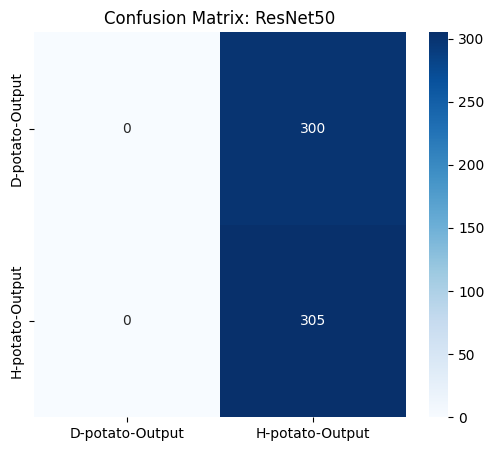

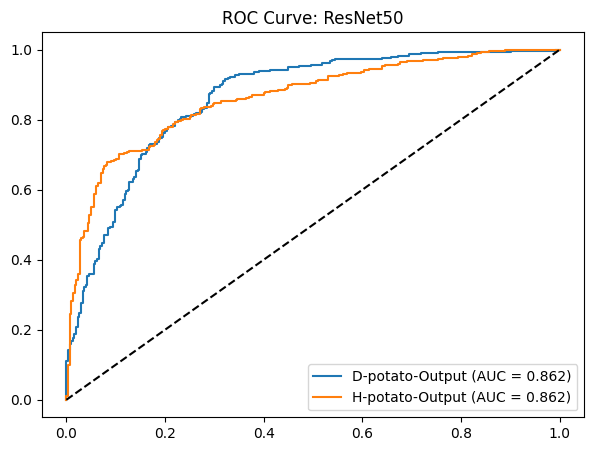

19/19 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step

MobileNetV2 RESULTS
Test Time (Total): 37.26s
                 precision    recall  f1-score   support

D-potato-Output       0.98      0.99      0.99       300
H-potato-Output       0.99      0.98      0.99       305

       accuracy                           0.99       605
      macro avg       0.99      0.99      0.99       605
   weighted avg       0.99      0.99      0.99       605



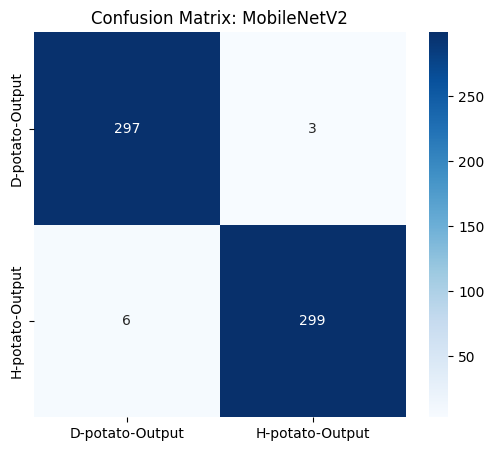

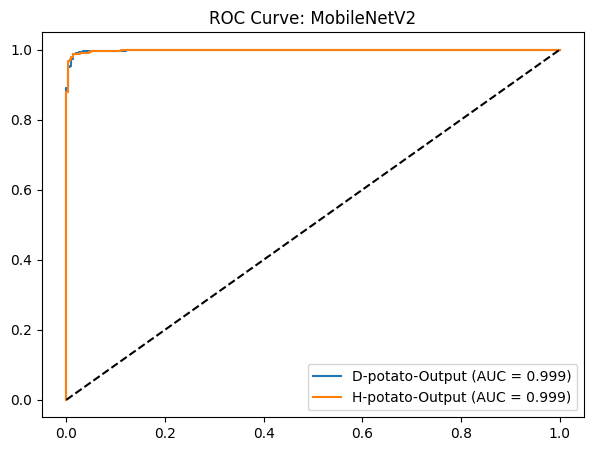

19/19 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step

InceptionV3 RESULTS
Test Time (Total): 39.31s
                 precision    recall  f1-score   support

D-potato-Output       0.96      0.96      0.96       300
H-potato-Output       0.96      0.96      0.96       305

       accuracy                           0.96       605
      macro avg       0.96      0.96      0.96       605
   weighted avg       0.96      0.96      0.96       605



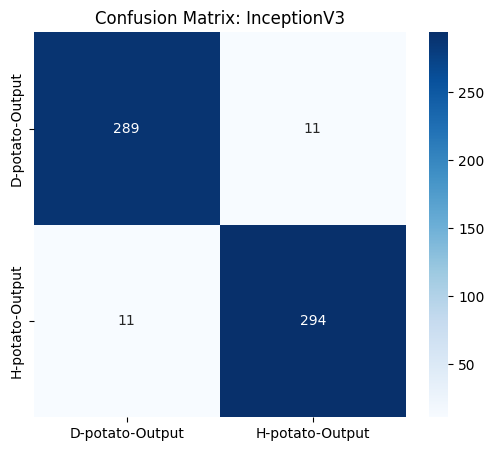

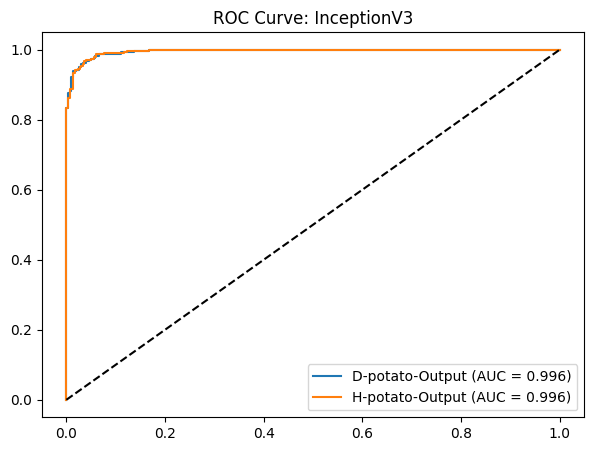

In [ ]:
def evaluate_model(name, model, generator):
    start_test = time.time()
    y_pred_probs = model.predict(generator)
    test_time = time.time() - start_test

    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.classes
    class_labels = list(generator.class_indices.keys())

    # Metrics
    print(f"\n{'='*20}\n{name} RESULTS\n{'='*20}")
    print(f"Test Time (Total): {test_time:.2f}s")
    print(classification_report(y_true, y_pred, target_names=class_labels))

    # Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d',
                cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

    # ROC Curve
    plt.figure(figsize=(7, 5))
    for i, label in enumerate(class_labels):
        # Handle binary vs multiclass ROC
        fpr, tpr, _ = roc_curve(y_true == i, y_pred_probs[:, i])
        plt.plot(fpr, tpr, label=f'{label} (AUC = {auc(fpr, tpr):.3f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"ROC Curve: {name}")
    plt.legend()
    plt.show()

for name, model in models_dict.items():
    evaluate_model(name, model, test_generator)